# Person detection

This notebook shows you how to use the Person Detection Model which is one of the out of the box example model's in Google's Tensorflow for Microcontrollers library.

I got this notebook from Michael O'Cleirigh. Having had trouble to get this to work myself.
Here is a pointer to the original version:
[person detection notebook](https://colab.research.google.com/drive/1GkZrupSh0S4vPnIikFqWf_QuSJZarItN?usp=sharing)

In [1]:
from tflite_micro.python.tflite_micro import runtime
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

2026-03-12 10:41:53.863830: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/home/uli/.virtualenvs/AI-Pythonv3.12/lib/python3.12/site-packages/tflite_micro/python/tflite_micro/postinstall_check.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
interp = runtime.Interpreter.from_file("../models/person_detect_model.tflite")

Number of resource variables the model uses =  0


In [3]:
print("Expecting Person")
with open("../images/person_image_data.dat", "rb") as f:
    img = np.frombuffer(f.read(), dtype=np.int8)

Expecting Person


In [4]:
img = img.reshape((1, 96, 96, 1))   # H x W

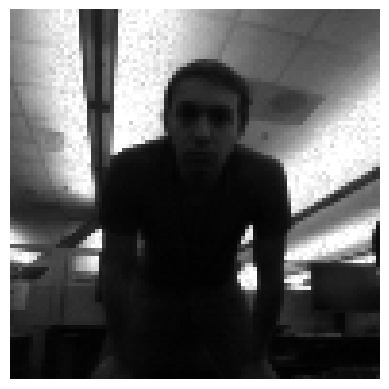

In [5]:
plt.imshow(img.reshape(96,96), cmap='gray')
plt.axis("off")
plt.show()

In [6]:
interp.set_input(img, 0)
interp.invoke()
output = interp.get_output(0)

In [7]:
y_q = output          # int8 array
y = 0.00390625 * (y_q.astype(np.float32) + 128)   # float32

In [8]:
class1 = y[0][0]
class2 = y[0][1]

In [9]:
print (f"not a person = {class1}, person = {class2}")

not a person = 0.05859375, person = 0.94140625


In [10]:
print("Expecting Not a Person")

Expecting Not a Person


In [11]:
with open("../images/no_person_image_data.dat", "rb") as f:
    img = np.frombuffer(f.read(), dtype=np.int8)

In [12]:
img = img.reshape((1, 96, 96, 1))   # H x W

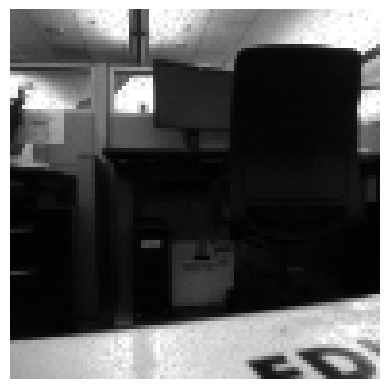

In [13]:
plt.imshow(img.reshape(96, 96), cmap='gray')
plt.axis("off")
plt.show()

In [ ]:
interp.set_input(img, 0)
interp.invoke()
output = interp.get_output(0)

In [ ]:
y_q = output          # int8 array
y = 0.00390625 * (y_q.astype(np.float32) + 128)   # float32

In [ ]:
class1 = y[0][0]
class2 = y[0][1]
print (f"not a person = {class1}, person = {class2}")